<a href="https://colab.research.google.com/github/aliantod/CNN-Image-Filter-Reversal/blob/main/Final_APS360_Project_Group_32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Modules

In [ ]:
import PIL
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


# Load Data

In [ ]:
# set up download stuff - safe to run as many times as you want
def kaggle_setup():
  """Sets up the shell environment in order to download the kaggle datasets.
  Do not edit or remove the API credentials unless you set up your own account and want to try that for whatever reason.
  """

  !mkdir ~/.kaggle #create the .kaggle folder in your root directory
  !echo '{"username":"kevinhu2290","key":"3e574637d0eba900228844021e1b33d6"}' > ~/.kaggle/kaggle.json #write kaggle API credentials to kaggle.json
  !chmod 600 ~/.kaggle/kaggle.json  # set permissions
  !pip install kaggle #install the kaggle library

In [ ]:
def download_landscapes(force=0):
  """Downloads the datasets being used for this project. Use option force=1 to force a redownload, other unspecified default is force=0 which will not redownload if the datasets already exist. force option is for if your data gets screwed up in your runtime or something, for whatever reasons.
  """

  if force:
    #!kaggle datasets download --force -d hshukla/landscapes -p /content/kaggle/ # this is too big, do not use

    !kaggle datasets download --force -d theblackmamba31/landscape-image-colorization -p /content/kaggle/

  else:
    #!kaggle datasets download -d hshukla/landscapes -p /content/kaggle/ # this is too big, do not use

    !kaggle datasets download -d theblackmamba31/landscape-image-colorization -p /content/kaggle/

  return

def download_indian_food(force=0):
  """Downloads the datasets being used for this project. Use option force=1 to force a redownload, other unspecified default is force=0 which will not redownload if the datasets already exist. force option is for if your data gets screwed up in your runtime or something, for whatever reasons.
  """

  if force:
    #!kaggle datasets download --force -d hshukla/landscapes -p /content/kaggle/ # this is too big, do not use

    !kaggle datasets download --force -d iamsouravbanerjee/indian-food-images-dataset -p /content/kaggle/

  else:
    #!kaggle datasets download -d hshukla/landscapes -p /content/kaggle/ # this is too big, do not use

    !kaggle datasets download -d iamsouravbanerjee/indian-food-images-dataset -p /content/kaggle/

  return

In [ ]:
def unzip_landscapes(force=0):
    """
    Unzips the landscape dataset to /content/datasets_raw/. The `force` option can be used
    to delete existing data and redo the unzipping process.
    """

    datasets_raw_path = Path("/content/datasets_raw")

    if force:
        # Remove and recreate the datasets_raw directory
        !rm -rf /content/datasets_raw
        !mkdir -p /content/datasets_raw

    if not datasets_raw_path.is_dir() or force:
        !mkdir -p /content/datasets_raw

        # Unzip the landscape dataset
        !unzip -q kaggle/landscape-image-colorization.zip -d datasets_raw/landscapes
        print("Landscape dataset unzipped successfully.")
    else:
        print("Landscape datasets have already been unzipped. Use force=1 to redo the process.")

    return

def unzip_indian_food(force=0):
    """
    Unzips the Indian food dataset to /content/datasets_raw/. The `force` option can be used
    to delete existing data and redo the unzipping process.
    """
    datasets_raw_path = Path("/content/datasets_raw")
    indian_food_path = datasets_raw_path / "indian_food"  # Check if the specific dataset is present

    if force:
        # Remove and recreate the datasets_raw directory
        !rm -rf /content/datasets_raw
        !mkdir -p /content/datasets_raw

    if not indian_food_path.is_dir() or force:  # Check for the specific dataset directory
        # Create datasets_raw directory if it doesn't exist
        !mkdir -p /content/datasets_raw

        # Unzip the Indian food dataset
        !unzip -q kaggle/indian-food-images-dataset.zip -d datasets_raw/indian_food
        print("Indian food dataset unzipped successfully.")
    else:
        print("Indian food dataset has already been unzipped. Use force=1 to redo the process.")

    return

def organize_landscapes():
    """
    Reorganizes the landscape dataset after unzipping. If the dataset is already organized,
    this function will notify the user. Ensure that the unzipped data exists in
    /content/datasets_raw/landscapes/ before running this function.
    """

    # Create the main datasets directory if it doesn't exist
    !mkdir -p /content/datasets/

    landscapes_path = Path("/content/datasets/landscapes/")

    if not landscapes_path.is_dir():
        # Create the main landscapes directory
        !mkdir -p /content/datasets/landscapes/truth

        # Move the original unprocessed landscape images to the "truth" folder
        !mv /content/datasets_raw/landscapes/* /content/datasets/landscapes/truth/

        # Initialize a list to store any directories processed
        data = []

        # Process each subdirectory in the landscape dataset
        for dir in os.listdir("/content/datasets_raw/landscapes/"):
            source_dir = os.path.join("/content/datasets_raw/landscapes/", dir)
            if os.path.isdir(source_dir):
                # Move all images to the "truth" folder
                !mv {source_dir}/* /content/datasets/landscapes/truth/
                data.append(dir)

        print(f"Landscape dataset reorganized. Processed directories: {data}")
    else:
        print("Landscape dataset has already been moved to landscapes/ dir.")

    return


def organize_indian_food():
  """If you need to reorganize your data after unzipping again, please make sure to delete your existing messed-up data in /content/datasets/indian_food/ by running '!rm -rf /content/datasets/indian_food/'. Then make sure you have your unzipped data in /content/datasets_raw/indian_food/ and rerun this function.
  """

  !mkdir /content/datasets/
  indian_food_path = Path("/content/datasets/indian_food/")

  if (indian_food_path.is_dir()==0):
    !mkdir /content/datasets/indian_food/
    !mkdir /content/datasets/indian_food/truth

    !mv /content/datasets_raw/indian_food/List\ of\ Indian\ Foods.txt /content/datasets/indian_food/

    data = []

    for dir in os.listdir("/content/datasets_raw/indian_food/Indian Food Images/Indian Food Images/"):
      !mv /content/datasets_raw/indian_food/Indian\ Food\ Images/Indian\ Food\ Images/{dir}/* /content/datasets/indian_food/truth/
      data.append(dir)

  else:
    print("Indian food dataset has already been moved to indian_food/ dir.")

  return


In [ ]:
def resize_img(img_arr, path):
  """ Resize image found in path (type string) to be 150x150. Images smaller than 150x150 to be deleted. Crop non-square images to be square before resizing down to 150x150.
  """

  # crop the longer dimension to be the same as the shorter one

  height = img_arr.shape[0]
  width = img_arr.shape[1]
  smaller = height if (height <= width) else width
  corner1 = int(height/2 - smaller/2)
  corner2 = int(height/2 + smaller/2)
  corner3 = int(width/2 - smaller/2)
  corner4 = int(width/2 + smaller/2)


  img_arr = img_arr[corner1:corner2, corner3:corner4, 0:3] # square, can resize down to 150x150 with no distortion

  img = PIL.Image.fromarray(img_arr)
  resized_img = img.resize((150, 150))
  resized_img.save(path)

  return

def resize_folder(folder_path, target_size=(150, 150)):
    folder_path = Path(folder_path)  # Ensure path handling
    if not folder_path.is_dir():
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    print(f"Processing folder: {folder_path}")

    for file_name in os.listdir(folder_path):
        file_path = folder_path / file_name
        if file_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
            try:
                with Image.open(file_path) as img:
                    resized_img = img.resize(target_size)
                    resized_img.save(file_path)
                    print(f"Resized and saved: {file_path}")
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        else:
            print(f"Skipping non-image file: {file_path}")


# def rename_data(path_str):
#   """3900-4000 indian foods (usually 3976), 7000-7129 (usually 7129) landscapes
#   Renames all the data at the given path_str to be of the format
#   0XXXX.jpb
#   For indian food, XXXX ranges from 0000 to (n_foods-1) (usually 3976-1)
#   i.e. [00000.jpg, 03975.jpg]
#   For landscapes, XXXX ranges from 0000 to (n_landscapes-1) (usually 7129-1)
#   i.e. [00000.jpg, 07128.jpg]

#   path_str should be a path of type string looking like below:
#   /content/datasets/indian_food/truth/
#   /content/datasets/landscapes/truth/
#   """

#   l_og_names = []
#   for og_name in os.listdir(path_str):
#     l_og_names.append(og_name)


#   if "00000.jpg" in l_og_names:
#     print("Data in path has already been renamed to 0XXXX.jpg convention!")
#     return

#   i = 0
#   for og_name in l_og_names:
#     new_name = str(i).rjust(5, "0")
#     !mv {path_str}/{og_name} {path_str}/{new_name}.jpg

#     i += 1

#   return

import os

def rename_data(path_str):
    """
    Renames all the data in the given directory to follow the format 0XXXX.jpg.

    - For Indian food: 00000.jpg to (n_foods-1).jpg
    - For landscapes: 00000.jpg to (n_landscapes-1).jpg

    Parameters:
    path_str (str): Path to the folder containing images.

    Returns:
    None
    """

    l_og_names = []

    # Collect all file names in the directory
    for og_name in os.listdir(path_str):
        file_path = os.path.join(path_str, og_name)
        # Ensure only image files are included
        if os.path.isfile(file_path) and file_path.lower().endswith(('.jpg', '.jpeg', '.png')):
            l_og_names.append(og_name)

    # Check if files have already been renamed
    if "00000.jpg" in l_og_names:
        print("Data in the path has already been renamed to 0XXXX.jpg convention!")
        return

    # Rename files
    i = 0
    for og_name in l_og_names:
        new_name = str(i).rjust(5, "0") + ".jpg"
        old_path = os.path.join(path_str, og_name)
        new_path = os.path.join(path_str, new_name)
        os.rename(old_path, new_path)
        i += 1

    print(f"Renamed {i} files to 0XXXX.jpg format.")


In [ ]:
#if you fuck up and want to retry

# code to remove everything
!rm -rf /content/kaggle/
!rm -rf /content/datasets_raw/
!rm -rf /content/datasets/

In [ ]:
kaggle_setup()
print('\n')

In [ ]:
download_landscapes(1)
print('\n')
unzip_landscapes(1)
print('\n')
organize_landscapes()
print('\n')

Dataset URL: https://www.kaggle.com/datasets/theblackmamba31/landscape-image-colorization
License(s): unknown
 93% 178M/192M [00:01<00:00, 157MB/s]
100% 192M/192M [00:01<00:00, 152MB/s]


Landscape dataset unzipped successfully.


Landscape dataset reorganized. Processed directories: []




In [ ]:
!mv /content/datasets_raw/landscapes/landscape\ Images/color/* /content/datasets/landscapes/truth/

In [ ]:
download_indian_food(1)
print('\n')
unzip_indian_food(1)
print('\n')
organize_indian_food()
print('\n')

Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/indian-food-images-dataset
License(s): other
 96% 340M/355M [00:05<00:00, 74.7MB/s]
100% 355M/355M [00:05<00:00, 66.7MB/s]


Indian food dataset unzipped successfully.






In [ ]:
from PIL import Image  # Import the Image module

resize_folder('/content/datasets/indian_food/truth/')

# need to run this twice for some dumb reason
# too lazy to debug this please just run this code block and then run the code block underneath and repeat until the block under this one says that everything is 150*150

# ONLY THEN run rename_data

Processing folder: /content/datasets/indian_food/truth
Resized and saved: /content/datasets/indian_food/truth/7c8975ad6b.jpg
Resized and saved: /content/datasets/indian_food/truth/60c3bd8f1c.jpg
Resized and saved: /content/datasets/indian_food/truth/a868af23e1.jpg
Resized and saved: /content/datasets/indian_food/truth/1efbacea88.jpg
Resized and saved: /content/datasets/indian_food/truth/6b2468cb2e.jpg
Resized and saved: /content/datasets/indian_food/truth/1fa96c5241.jpg
Resized and saved: /content/datasets/indian_food/truth/7c66754e76.jpg
Resized and saved: /content/datasets/indian_food/truth/7c39f5b50f.jpg
Resized and saved: /content/datasets/indian_food/truth/0ff068e0ea.jpg
Resized and saved: /content/datasets/indian_food/truth/1f75bd9f79.jpg
Resized and saved: /content/datasets/indian_food/truth/11f01c4f78.jpg
Resized and saved: /content/datasets/indian_food/truth/07fb5e63b9.jpg
Resized and saved: /content/datasets/indian_food/truth/4c890843b5.jpg
Resized and saved: /content/dataset

In [ ]:
resize_folder('/content/datasets/landscapes/truth/landscape Images/color')

Streaming output truncated to the last 5000 lines.
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/1908.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/5878.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/1169.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/4269.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/5849.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/1624.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/1953.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/1481.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/3669.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/3030.jpg
Resized and saved: /content/datasets/landscapes/truth/landscape Images/color/2009.jpg
Res

In [ ]:
resize_folder('/content/datasets/landscapes/truth/')

Processing folder: /content/datasets/landscapes/truth
Skipping non-image file: /content/datasets/landscapes/truth/landscape Images


In [ ]:
l_if_img_shapes = []
l_if_wrong_size = []
num_if_too_small = 0
num_if_right_size = 0

l_images = []
for image_name in os.listdir('/content/datasets/indian_food/truth/'):
  l_images.append(image_name)

for i in range(0, len(l_images)):
  #file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  file_name = l_images[i]
  if_size_test = np.array(PIL.Image.open(f'/content/datasets/indian_food/truth/{file_name}'))

  if (if_size_test.shape[0] == 150) and (if_size_test.shape[1] == 150):
    num_if_right_size += 1
    l_if_img_shapes.append(if_size_test.shape)
  elif (if_size_test.shape[0] > 150) and (if_size_test.shape[1] > 150):
    l_if_img_shapes.append(if_size_test.shape)
    l_if_wrong_size.append(if_size_test)
    resize_img(if_size_test, f'/content/datasets/indian_food/truth/{file_name}.jpg')
    print(i)
  else:
    num_if_too_small += 1
    #print(if_size_test.shape)

arr_if_img_shapes = np.array(l_if_img_shapes)

print(f"There are {num_if_too_small} indian food images that are less than 150*150")
print(f"There are {len(l_if_wrong_size)} indian food images that are more than 150*150")
print("Number of 150x150 indian foods:", num_if_right_size)
print()
print("Smallest indian food image dims:", np.min(arr_if_img_shapes, axis=0))
print("Largest indian food image dims:", np.max(arr_if_img_shapes, axis=0))


for image in l_if_wrong_size:
  print(image.shape)

There are 0 indian food images that are less than 150*150
There are 0 indian food images that are more than 150*150
Number of 150x150 indian foods: 3976

Smallest indian food image dims: [150 150   3]
Largest indian food image dims: [150 150   3]


In [ ]:
l_if_img_shapes_landscapes = []
l_if_wrong_size_landscapes = []
num_if_too_small_landscapes = 0
num_if_right_size_landscapes = 0

# Update this path to the correct folder containing the images
landscapes_path = '/content/datasets/landscapes/truth/'
l_images_landscapes = [f for f in os.listdir(landscapes_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

for i, file_name_landscapes in enumerate(l_images_landscapes):
    file_path = os.path.join(landscapes_path, file_name_landscapes)  # Construct the file path
    try:
        if_size_test_landscapes = np.array(Image.open(file_path))  # Open the image
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue

    # Check dimensions and resize if necessary
    if (if_size_test_landscapes.shape[0] == 150) and (if_size_test_landscapes.shape[1] == 150):
        num_if_right_size_landscapes += 1
        l_if_img_shapes_landscapes.append(if_size_test_landscapes.shape)
    elif (if_size_test_landscapes.shape[0] > 150) and (if_size_test_landscapes.shape[1] > 150):
        l_if_img_shapes_landscapes.append(if_size_test_landscapes.shape)
        l_if_wrong_size_landscapes.append(if_size_test_landscapes)
        resize_img(if_size_test_landscapes, file_path)
        print(f"Resized: {file_path}")
    else:
        num_if_too_small_landscapes += 1

# Convert collected shapes into a NumPy array
arr_if_img_shapes_landscapes = np.array(l_if_img_shapes_landscapes)

print(f"There are {num_if_too_small_landscapes} landscape images that are less than 150x150.")
print(f"There are {len(l_if_wrong_size_landscapes)} landscape images that are more than 150x150.")
print("Number of 150x150 landscape images:", num_if_right_size_landscapes)
print()
if len(arr_if_img_shapes_landscapes) > 0:  # Avoid errors when the array is empty
    print("Smallest landscape image dims:", np.min(arr_if_img_shapes_landscapes, axis=0))
    print("Largest landscape image dims:", np.max(arr_if_img_shapes_landscapes, axis=0))

# Print shapes of wrongly sized images
for image in l_if_wrong_size_landscapes:
    print(image.shape)


There are 0 landscape images that are less than 150x150.
There are 0 landscape images that are more than 150x150.
Number of 150x150 landscape images: 0



In [ ]:
l_if_img_shapes = []
l_if_wrong_size = []
num_if_too_small = 0
num_if_right_size = 0

l_images = []
for image_name in os.listdir('/content/datasets/indian_food/truth/'):
  l_images.append(image_name)

for i in range(0, len(l_images)):
  #file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  file_name = l_images[i]
  if_size_test = np.array(PIL.Image.open(f'/content/datasets/indian_food/truth/{file_name}'))

  if (if_size_test.shape[0] == 150) and (if_size_test.shape[1] == 150):
    num_if_right_size += 1
    l_if_img_shapes.append(if_size_test.shape)
  elif (if_size_test.shape[0] > 150) and (if_size_test.shape[1] > 150):
    l_if_img_shapes.append(if_size_test.shape)
    l_if_wrong_size.append(if_size_test)
    resize_img(if_size_test, f'/content/datasets/indian_food/truth/{file_name}.jpg')
    print(i)
  else:
    num_if_too_small += 1
    #print(if_size_test.shape)

arr_if_img_shapes = np.array(l_if_img_shapes)

print(f"There are {num_if_too_small} indian food images that are less than 150*150")
print(f"There are {len(l_if_wrong_size)} indian food images that are more than 150*150")
print("Number of 150x150 indian foods:", num_if_right_size)
print()
print("Smallest indian food image dims:", np.min(arr_if_img_shapes, axis=0))
print("Largest indian food image dims:", np.max(arr_if_img_shapes, axis=0))


for image in l_if_wrong_size:
  print(image.shape)

There are 0 indian food images that are less than 150*150
There are 0 indian food images that are more than 150*150
Number of 150x150 indian foods: 3976

Smallest indian food image dims: [150 150   3]
Largest indian food image dims: [150 150   3]


In [ ]:
l_if_img_shapes = []
l_if_wrong_size = []
num_if_too_small = 0
num_if_right_size = 0

l_images = []
for image_name in os.listdir('/content/datasets/landscapes/truth/landscape Images/color'):
  l_images.append(image_name)

for i in range(0, len(l_images)):
  #file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  file_name = l_images[i]
  if_size_test = np.array(PIL.Image.open(f'/content/datasets/landscapes/truth/landscape Images/color/{file_name}'))

  if (if_size_test.shape[0] == 150) and (if_size_test.shape[1] == 150):
    num_if_right_size += 1
    l_if_img_shapes.append(if_size_test.shape)
  elif (if_size_test.shape[0] > 150) and (if_size_test.shape[1] > 150):
    l_if_img_shapes.append(if_size_test.shape)
    l_if_wrong_size.append(if_size_test)
    resize_img(if_size_test, f'/content/datasets/landscapes/truth/landscape Images/color/{file_name}.jpg')
    print(i)
  else:
    num_if_too_small += 1
    #print(if_size_test.shape)

arr_if_img_shapes = np.array(l_if_img_shapes)

print(f"There are {num_if_too_small} landscape food images that are less than 150*150")
print(f"There are {len(l_if_wrong_size)} landscape food images that are more than 150*150")
print("Number of 150x150 landscape:", num_if_right_size)
print()
print("Smallest landscape image dims:", np.min(arr_if_img_shapes, axis=0))
print("Largest landscape image dims:", np.max(arr_if_img_shapes, axis=0))


for image in l_if_wrong_size:
  print(image.shape)

There are 0 landscape food images that are less than 150*150
There are 0 landscape food images that are more than 150*150
Number of 150x150 landscape: 7129

Smallest landscape image dims: [150 150   3]
Largest landscape image dims: [150 150   3]


In [ ]:

import os

directory_path = '/content/datasets/indian_food/truth/'

directory_files = os.listdir(directory_path)
print(len(directory_files))

i = 0
for file in directory_files:
  if i < 1976:
    #print(f'rm -rf {directory_path + file}')
    #os.system(f'rm -rf {directory_path + file}') # fix this

    i += 1
  else:
    break




3976


In [ ]:
import os

directory_path = '/content/datasets/landscapes/truth/landscape Images/color/'

directory_files = os.listdir(directory_path)
print(f"Initial file count: {len(directory_files)}")

# Use a counter to limit deletion to 3000 files
i = 0
for file in directory_files:
    if i < 3000:
        file_path = os.path.join(directory_path, file)

        # Debug: Check if the file path exists and is accessible
        if os.path.exists(file_path):
            os.system(f'rm -rf "{file_path}"')  # Quote the path to handle spaces
            i += 1
        else:
            print(f"File not found or inaccessible: {file_path}")
    else:
        break

# Reload directory and check the remaining files
remaining_files = os.listdir(directory_path)
print(f"Remaining file count: {len(remaining_files)}")


Initial file count: 7129
Remaining file count: 4129


In [ ]:
import os

directory_path = '/content/datasets/indian_food/truth'

directory_files = os.listdir(directory_path)
print(f"Initial file count: {len(directory_files)}")

# Use a counter to limit deletion to 3000 files
i = 0
for file in directory_files:
    if i < 1976:
        file_path = os.path.join(directory_path, file)

        # Debug: Check if the file path exists and is accessible
        if os.path.exists(file_path):
            os.system(f'rm -rf "{file_path}"')  # Quote the path to handle spaces
            i += 1
        else:
            print(f"File not found or inaccessible: {file_path}")
    else:
        break

# Reload directory and check the remaining files
remaining_files = os.listdir(directory_path)
print(f"Remaining file count: {len(remaining_files)}")


Initial file count: 3976
Remaining file count: 2000


In [ ]:
# will take like 20 mins but is worth it
# this makes iterating through the datasets possible
rename_data("/content/datasets/indian_food/truth/")
print('\n')

Renamed 2000 files to 0XXXX.jpg format.




In [ ]:
rename_data("/content/datasets/landscapes/truth/")

Renamed 4129 files to 0XXXX.jpg format.


In [ ]:
n_foods = 0
for food in os.listdir("/content/datasets/indian_food/truth/"):
  n_foods += 1

print(n_foods, "indian foods")

2000 indian foods


In [ ]:
n_landscapes = 0
for landscape in os.listdir("/content/datasets/landscapes/truth/"):
  n_landscapes += 1

print(n_landscapes, "number of landscapes")

4129 number of landscapes


In [ ]:
l_indian_food_img_shapes = []
l_indian_food_wrong_size = []
num_indian_food_too_small = 0
num_indian_food_right_size = 0
for i in range(0, n_foods):
  file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  indian_food_size_test = np.array(PIL.Image.open(f'/content/datasets/indian_food/truth/{file_name}.jpg'))

  if (indian_food_size_test.shape[0] == 150) and (indian_food_size_test.shape[1] == 150):
    num_indian_food_right_size += 1
    l_indian_food_img_shapes.append(indian_food_size_test.shape)
  elif (indian_food_size_test.shape[0] > 150) and (indian_food_size_test.shape[1] > 150):
    l_indian_food_img_shapes.append(indian_food_size_test.shape)
    l_indian_food_wrong_size.append(indian_food_size_test)
    resize_img(indian_food_size_test, f'/content/datasets/indian_food/truth/{file_name}.jpg')
    print(i)
  else:
    num_indian_food_too_small += 1
    #print(indian_food_size_test.shape)

In [ ]:
l_landscapes_img_shapes = []
l_landscapes_wrong_size = []
num_landscapes_too_small = 0
num_landscapes_right_size = 0
for i in range(0, n_foods):
  file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  landscapes_size_test = np.array(PIL.Image.open(f'/content/datasets/landscapes/truth/{file_name}.jpg'))

  if (landscapes_size_test.shape[0] == 150) and (landscapes_size_test.shape[1] == 150):
    num_landscapes_right_size += 1
    l_landscapes_img_shapes.append(landscapes_size_test.shape)
  elif (landscapes_size_test.shape[0] > 150) and (landscapes_size_test.shape[1] > 150):
    l_landscapes_img_shapes.append(landscapes_size_test.shape)
    l_landscapes_wrong_size.append(landscapes_size_test)
    resize_img(landscapes_size_test, f'/content/datasets/landscapes/truth/landscape Images/color/{file_name}.jpg')
    print(i)
  else:
    num_landscapes_too_small += 1
    #print(landscapes_size_test.shape)

In [ ]:
l_landscape_img_shapes = []
num_landscapes_too_small = 0
for i in range(0, n_landscapes):
  file_name = str(i).rjust(5, "0") # pads zeros to the left of iter i
  landscape_size_test = np.array(PIL.Image.open(f'/content/datasets/landscapes/truth/landscape Images/color/{file_name}.jpg'))

  if (landscape_size_test.shape[0] > 149) and (landscape_size_test.shape[0] > 149):
    l_landscape_img_shapes.append(landscape_size_test.shape)
  else:
    num_landscapes_too_small += 1
    #print(landscape_size_test.shape)

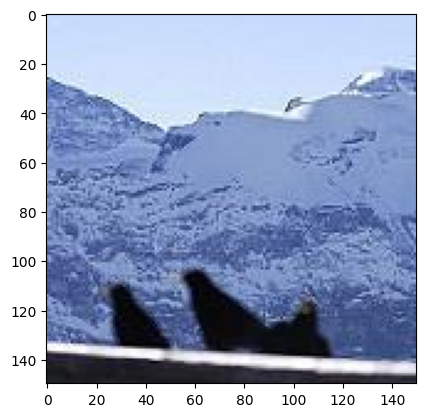

In [ ]:
landscape_test_img = np.array(PIL.Image.open('/content/datasets/landscapes/truth/00001.jpg'))
plt.imshow(landscape_test_img)

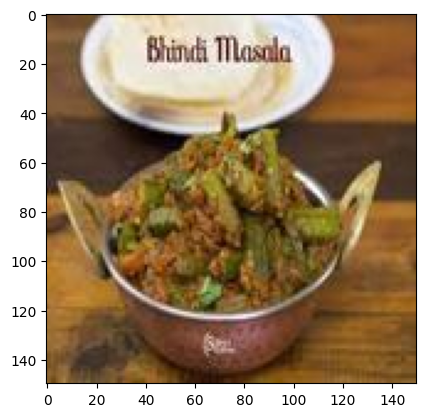

In [ ]:
indian_food_test_img = np.array(PIL.Image.open('/content/datasets/indian_food/truth/00001.jpg'))
plt.imshow(indian_food_test_img)

In [ ]:
arr_landscape_img_shapes = np.array(l_landscape_img_shapes)
print(f"There are {arr_landscape_img_shapes.shape[0]} landscape images that are at least 150*150")
print(f"There are {num_landscapes_too_small} landscape images that are less than 150*150")

print("Smallest landscape image dims:", np.min(arr_landscape_img_shapes, axis=0))
print("Largest landscape image dims:", np.max(arr_landscape_img_shapes, axis=0))

NameError: name 'l_landscape_img_shapes' is not defined

In [ ]:
arr_indian_food_img_shapes = np.array(l_indian_food_img_shapes)
print(f"There are {arr_indian_food_img_shapes.shape[0]} indian food images that are at least 150*150")
print(f"There are {num_indian_food_too_small} indian food images that are less than 150*150")

print("Smallest indian food image dims:", np.min(arr_indian_food_img_shapes, axis=0))
print("Largest indian food image dims:", np.max(arr_indian_food_img_shapes, axis=0))

print("number of 150x150 indian foods:", num_indian_food_right_size)

for image in l_indian_food_wrong_size:
  print(image.shape)

There are 2000 indian food images that are at least 150*150
There are 0 indian food images that are less than 150*150
Smallest indian food image dims: [150 150   3]
Largest indian food image dims: [150 150   3]
number of 150x150 indian foods: 2000


# Process Data
1. Apple greyscale, sepia, and invert filters

In [ ]:
!mkdir /content/datasets/indian_food/grayscale/
!mkdir /content/datasets/indian_food/sepia/
!mkdir /content/datasets/indian_food/inverted/

In [ ]:
!mkdir /content/datasets/landscapes/grayscale/
!mkdir /content/datasets/landscapes/sepia/
!mkdir /content/datasets/landscapes/inverted/

# file structure:
'''
content
  indian_food
    truth
      00000.jpg # (food img 00000)
      0XXXX.jpg # (food img 0XXXX)
    grayscale
      00000.jpg # greyscale version of (food img 00000)
      0XXXX.jpg # greyscale version of (food img 0XXXX)
    sepia
      00000.jpg # sepia version of (food img 00000)
      0XXXX.jpg # sepia version of (food img 0XXXX)
    invert
      00000.jpg # invert version of (food img 00000)
      0XXXX.jpg # invert version of (food img 0XXXX)
  landscapes
    truth
      00000.jpg # (landscape img 00000)
      0XXXX.jpg # (landscape img 00000)
    grayscale
      00000.jpg # greyscale version of (landscape img 00000)
      0XXXX.jpg # greyscale version of (landscape img 0XXXX)
    sepia
      00000.jpg # sepia version of (landscape img 00000)
      0XXXX.jpg # sepia version of (landscape img 0XXXX)
    invert
      00000.jpq # invert version of (landscape img 00000)
      0XXXX.jpq # invert version of (landscape img 0XXXX)
'''



'\ncontent\n  indian_food\n    truth\n      00000.jpg # (food img 00000)\n      0XXXX.jpg # (food img 0XXXX)\n    grayscale\n      00000.jpg # greyscale version of (food img 00000)\n      0XXXX.jpg # greyscale version of (food img 0XXXX)\n    sepia\n      00000.jpg # sepia version of (food img 00000)\n      0XXXX.jpg # sepia version of (food img 0XXXX)\n    invert\n      00000.jpg # invert version of (food img 00000)\n      0XXXX.jpg # invert version of (food img 0XXXX)\n  landscapes\n    truth\n      00000.jpg # (landscape img 00000)\n      0XXXX.jpg # (landscape img 00000)\n    grayscale\n      00000.jpg # greyscale version of (landscape img 00000)\n      0XXXX.jpg # greyscale version of (landscape img 0XXXX)\n    sepia\n      00000.jpg # sepia version of (landscape img 00000)\n      0XXXX.jpg # sepia version of (landscape img 0XXXX)\n    invert\n      00000.jpq # invert version of (landscape img 00000)\n      0XXXX.jpq # invert version of (landscape img 0XXXX)\n'

In [ ]:
from PIL import Image

# Grayscale filter
def apply_grayscale(image):
    grayscale = np.dot(image[...,:3], [0.299, 0.587, 0.114]) # dot product
    return np.stack((grayscale, grayscale, grayscale), axis=-1).astype(np.uint8)

# Sepia filter
def apply_sepia(image):
    sepia = np.copy(image)
    tr = 0.393 * image[:,:,0] + 0.769 * image[:,:,1] + 0.189 * image[:,:,2]
    tg = 0.349 * image[:,:,0] + 0.686 * image[:,:,1] + 0.168 * image[:,:,2]
    tb = 0.272 * image[:,:,0] + 0.534 * image[:,:,1] + 0.131 * image[:,:,2]
    sepia[:,:,0] = np.clip(tr, 0, 255)
    sepia[:,:,1] = np.clip(tg, 0, 255)
    sepia[:,:,2] = np.clip(tb, 0, 255)
    return sepia.astype(np.uint8)

# Inverted filter
def apply_inverted(image):
    inverted = 255 - image
    return inverted.astype(np.uint8)

# general form for one channel is
# p_r * a + p_g * b + p_b * c + d
# three rgb
# 3*4 = 12

In [ ]:
base_path = '/content/datasets/'

# Create directories for Indian food and landscapes
#image_types = ['indian_food','landscapes']
image_types = ['indian_food']
for image_type in image_types:
    os.makedirs(os.path.join(base_path, image_type, 'truth'), exist_ok=True)

print("Directory structure created successfully.")

Directory structure created successfully.


In [ ]:
from pathlib import Path
import os
import numpy as np
from PIL import Image

# Directory structure: 6 directories for different filters and types (Indian food, landscapes)
filters = ['grayscale', 'sepia', 'inverted']
#image_types = ['indian_food', 'landscapes']  # Global var image_types
image_types = ['landscapes']

def create_dirs():
    """Create the directories for filtered images."""
    for image_type in image_types:
        for filter_type in filters:
            dir_path = Path(f"/content/datasets/{image_type}/{filter_type}/")
            dir_path.mkdir(parents=True, exist_ok=True)

def save_filtered_images(image_type, apply_filter, filter_name):
    """Apply the filter and save the images in the corresponding directory."""

    # Define source directory based on the image type
    if image_type == 'indian_food':
        source_dir = Path(f"/content/datasets/{image_type}/truth/")
    elif image_type == 'landscapes':
        source_dir = Path(f"/content/datasets/{image_type}/truth/")
    else:
        raise ValueError(f"Unknown image type: {image_type}")

    # Define destination directory
    dest_dir = Path(f"/content/datasets/{image_type}/{filter_name}/")

    # Create destination directory if it doesn't exist
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Process each file in the source directory
    for file_name in os.listdir(source_dir):
        file_path = source_dir / file_name

        # Ensure the file is an image
        if file_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
            img = np.array(Image.open(file_path))
            filtered_img = apply_filter(img)
            output_img = Image.fromarray(filtered_img)
            output_img.save(dest_dir / file_name)

# Create directories
create_dirs()

# Apply filters and save images
for image_type in image_types:
    save_filtered_images(image_type, apply_grayscale, 'grayscale')
    save_filtered_images(image_type, apply_sepia, 'sepia')
    save_filtered_images(image_type, apply_inverted, 'inverted')

print("Filtered images saved successfully.")


Filtered images saved successfully.


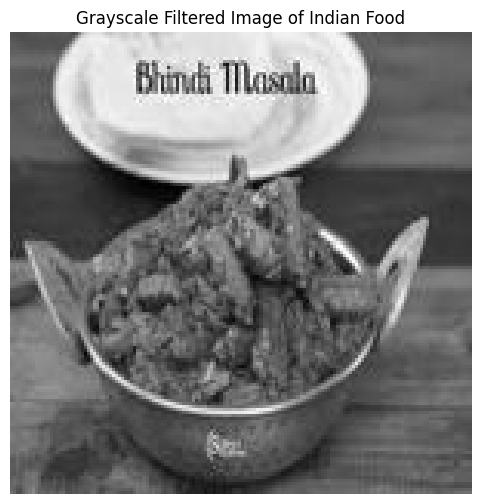

In [ ]:
# example

image_path = '/content/datasets/indian_food/grayscale/00001.jpg'

# Load the image
filtered_image = Image.open(image_path)
filtered_image_np = np.array(filtered_image)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(filtered_image_np)
plt.axis('off')  # Turn off axis labels
plt.title('Grayscale Filtered Image of Indian Food')
plt.show()


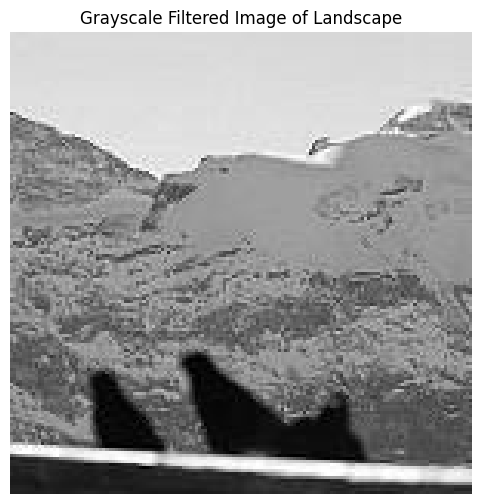

In [ ]:
# example

image_path = '/content/datasets/landscapes/grayscale/00001.jpg'

# Load the image
filtered_image = Image.open(image_path)
filtered_image_np = np.array(filtered_image)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(filtered_image_np)
plt.axis('off')  # Turn off axis labels
plt.title('Grayscale Filtered Image of Landscape')
plt.show()


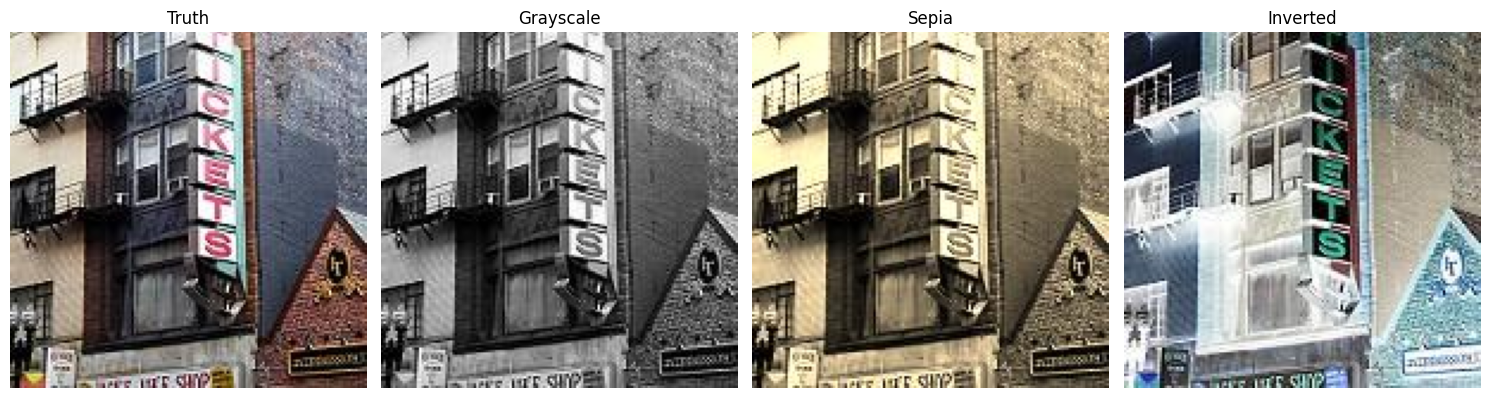

In [ ]:
# Define dataset paths
dataset_path = '/content/datasets/landscapes'
filter_names = ["truth", "grayscale", "sepia", "inverted"]

# Select an example image from the "truth" folder
example_image_path = os.path.join(dataset_path, "truth", "00001.jpg")

# Load the original image
original_image = Image.open(example_image_path)

# Prepare subplots
plt.figure(figsize=(15, 5))

# Iterate through the filters and apply them
for i, filter_name in enumerate(filter_names):
    # Get the corresponding filtered image path
    filtered_image_path = os.path.join(dataset_path, filter_name, os.path.basename(example_image_path))

    # Load the filtered image
    filtered_image = Image.open(filtered_image_path)
    filtered_image_np = np.array(filtered_image)

    # Display the image
    plt.subplot(1, 4, i + 1)
    plt.imshow(filtered_image_np)
    plt.axis('off')
    plt.title(f"{filter_name.capitalize()}")

plt.tight_layout()
plt.show()


In [ ]:
# RUN THIS CODE, this is to make sure the truth folder for landscapes doesnt have a bunch of shit like landscape Images/color etc.

import os
import shutil
from pathlib import Path

# Define source and destination directories
source_dir = Path("/content/datasets/landscapes/truth/landscape Images/color/")
destination_dir = Path("/content/datasets/landscapes/truth/")

# Ensure the destination directory exists
destination_dir.mkdir(parents=True, exist_ok=True)

# Move all files from source to destination
for file_name in os.listdir(source_dir):
    source_file = source_dir / file_name
    destination_file = destination_dir / file_name

    # Check if the file is not a directory
    if source_file.is_file():
        shutil.move(str(source_file), str(destination_file))
        print(f"Moved: {source_file} -> {destination_file}")

print("All files have been moved successfully.")


Moved: /content/datasets/landscapes/truth/landscape Images/color/3872.jpg -> /content/datasets/landscapes/truth/3872.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/1587.jpg -> /content/datasets/landscapes/truth/1587.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/303.jpg -> /content/datasets/landscapes/truth/303.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/4122.jpg -> /content/datasets/landscapes/truth/4122.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/6158.jpg -> /content/datasets/landscapes/truth/6158.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/4878.jpg -> /content/datasets/landscapes/truth/4878.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/4236.jpg -> /content/datasets/landscapes/truth/4236.jpg
Moved: /content/datasets/landscapes/truth/landscape Images/color/2628.jpg -> /content/datasets/landscapes/truth/2628.jpg
Moved: /content/datasets/landscape

In [ ]:
import shutil
from pathlib import Path

# Define the directory to clear
landscape_images_dir = Path("/content/datasets/landscapes/truth/landscape Images/")

# Check if the directory exists
if landscape_images_dir.exists() and landscape_images_dir.is_dir():
    # Remove the directory and all its contents
    shutil.rmtree(landscape_images_dir)
    print(f"Removed: {landscape_images_dir}")
else:
    print(f"Directory not found: {landscape_images_dir}")


Removed: /content/datasets/landscapes/truth/landscape Images


# Primary Model

In [ ]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader

In [ ]:
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = labels.long()  # Ensure labels are of Long type for CrossEntropyLoss
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        predictions = torch.argmax(outputs, dim=1)  # Get predicted class
        total_err += (predictions != labels).sum().item()
        total_loss += loss.item()
        total_epoch += labels.size(0)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

def get_indices(dataset):
  indices = []
  for i in range(len(dataset)):
    indices.append(i)

  return indices

def itr_merge(*itrs):
    for itr in itrs:
        for v in itr:
            yield v

def get_data_loader(target_filters, target_imgs, batch_size):
  """ Loads images of target classes and filters, splits the data into training, validation
  and testing datasets. Returns data loaders for the three preprocessed datasets.

  Args:
      target_classes: A list of strings denoting the name of the desired
                      classes. Should be a subset of the argument 'classes'
      batch_size: A int representing the number of samples per batch

  Returns:
      train_loader: iterable training dataset organized according to batch size
      val_loader: iterable validation dataset organized according to batch size
      test_loader: iterable testing dataset organized according to batch size
      classes: A list of strings denoting the name of each class
  """

  filters = ["grayscale", "sepia", "inverted", "truth"]
  np.random.seed(1000)

  ########################################################################
  # The output of torchvision datasets are PILImage images of range [0, 1].
  # We transform them to Tensors of normalized range [-1, 1].

  transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Resize((150, 150)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
      # The original transforms.Resize code was not properly applied to the images.
      # The current format ensures it is applied to all images during dataset creation.





  # just do the whole loop for each of the 3-6 folders (1-2 * 3)

  for i, data_type in enumerate(target_imgs):
    #for j, filter in enumerate(target_filters):
      #path = f"/content/datasets/{data_type}/{filter}/"
      path = f"/content/datasets/{data_type}/"
      print(f"Currently loading data from {path}")

      curr_data = ImageFolder(path, transform=transform)
      curr_indices = get_indices(curr_data)

      split = int(len(curr_indices) * 0.7) # split at 80%
      val_test_split = int(len(curr_indices) * 0.85)

      train_indices, val_indices, test_indices = curr_indices[:split], curr_indices[split:val_test_split], curr_indices[val_test_split:]

      #if (i+j==0): # first iteration, create loaders
      if (i == 0):
        curr_train_sampler = SubsetRandomSampler(train_indices)
        curr_train_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=curr_train_sampler,
                                                  shuffle=True)
        curr_val_sampler = SubsetRandomSampler(val_indices)
        curr_val_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=curr_val_sampler,
                                                  shuffle=True)
        curr_test_sampler = SubsetRandomSampler(test_indices)
        curr_test_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=curr_test_sampler,
                                                  shuffle=True)

        train_loader = curr_train_loader
        val_loader = curr_val_loader
        test_loader = curr_test_loader

      else: # loader already exists, concatenate to end of existing loader

        temp_train_sampler = SubsetRandomSampler(train_indices)
        temp_train_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=temp_train_sampler,
                                                  shuffle=True)
        temp_val_sampler = SubsetRandomSampler(val_indices)
        temp_val_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=temp_val_sampler,
                                                  shuffle=True)
        temp_test_sampler = SubsetRandomSampler(test_indices)
        temp_test_loader = DataLoader(curr_data, batch_size=batch_size,
                                                  num_workers=1,
                                                  #sampler=temp_test_sampler,
                                                  shuffle=True)

        # we know that all three filters folders have the same amount of examples since we generated this ourselves. Each image appears once in truth, greyscale, sepia, and inverted
        # thus we don't need to worry about distribution - having the entirety of each filter folder in the data loader ends up creating equal 1/3rd distributions of each filter in the total dataset
        # furthermore, by shuffling after, images that are used in each of training, val, and test, are not seen in the other two as a different filtered image. Order of image names in each folder matches the others.
        # i.e. img X, appearing in greyscale training data, will appear as sepia img X in training and inverted img X in training. But no filtered version of img X will appear in any of the val or test datasets
        train_loader = itr_merge(curr_train_loader, temp_train_loader)
        val_loader = itr_merge(curr_val_loader, temp_val_loader)
        test_loader = itr_merge(curr_test_loader, temp_test_loader)

        curr_train_loader = train_loader
        curr_val_loader = val_loader
        curr_test_loader = test_loader

  # currently, train_loader order is:
  # food gray, food sepia, food invert, landscape gray, ...

  # dataloader will get shuffled upon creation of it's iterator

  return train_loader, val_loader, test_loader, filters


In [ ]:
target_filters = ["grayscale", "sepia", "inverted", "truth"]
target_imgs = ["indian_food"]

check_train_loader, check_val_loader, check_test_loader, check_filters = get_data_loader(target_filters, target_imgs, batch_size=1)

l_test_images = []
i = 0
for image, label in check_train_loader:
  if (i > 9):
    break
  else:
    sample_image = image[0]
    np_sample = sample_image.numpy().transpose(1, 2, 0)
    l_test_images.append(np_sample)
  i += 1


Currently loading data from /content/datasets/indian_food/


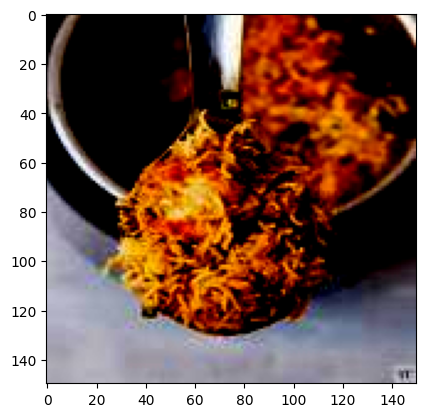

In [ ]:
plt.imshow(l_test_images[0])

# going through and displaying the list appears that the shuffling was done correctly - all three of grayscale, sepia, and inverted show up randomly in the first ten of the dataloader

# Training


In [ ]:
class PrimaryNet_Progress2(nn.Module):
    def __init__(self):
        super(PrimaryNet_Progress2, self).__init__()
        self.name = "primary"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)

        # Adjust fc1 input size to match the flattened conv2 output
        self.fc1 = nn.Linear(10 * 34 * 34, 32)
        self.fc2 = nn.Linear(32, 12)  # Predict 12 regression outputs

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Outputs 12 values
        return x

In [ ]:
def train_net(net, target_data, target_filters, batch_size=64, learning_rate=0.003, num_epochs=30):
    torch.manual_seed(1000)
    train_loader, val_loader, test_loader, filters = get_data_loader(target_filters, target_data, batch_size=batch_size)

    # Define the Loss function and optimizer
    criterion = nn.MSELoss() # ??? rmse
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    start_time = time.time()

    # Training loop
    for epoch in range(num_epochs):
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            # labels 0 or 1 or 2
            # convert to ['grayscale', etc]
            # get_truth_abcd('grayscale')
            # abcd = [ [red_a, red_b, red_c, red_d],
            #          [green_a, green_b, green_c, green_d],
            #          [blue_a, blue_b, blue_c, blue_d]]
            # abcd = np.array(abcd)

            # true_abcd_list = [get_truth_abcd(filters[label]) for label in labels]
            # true_abcd = torch.tensor(true_abcd_list, dtype=torch.float32)  # Shape (batch_size, 3, 4)
            # #true_abcd = true_abcd.view(true_abcd.size(0), -1)  # Reshape to (batch_size, 12)
            # true_abcd = true_abcd.view(-1, 12)

            true_abcd_list = [get_truth_abcd(target_filters[label.item()]) for label in labels]
            true_abcd = torch.tensor(true_abcd_list, dtype=torch.float32).to(inputs.device)
            true_abcd = true_abcd.view(inputs.size(0), -1)

            # Check and convert labels to Long if needed
            # Assuming labels should match [64, 12]
            #labels = labels.view(-1, 12)  # Reshape labels to match outputs shape

            labels = labels.long()  # Explicitly cast labels to Long
            if i % 100 == 0:
              print(f"Epoch {epoch}, Batch {i} - Labels dtype: {labels.dtype}, Unique values: {torch.unique(labels)}")  # Debugging output

            # Zero the parameter gradients
            optimizer.zero_grad()
            outputs = net(inputs)

            # Debugging: Print shapes and ranges
            # if i % 100 == 0:  # Only print every 100 batches to avoid clutter
            #     print(f"Batch {i}")
            #     print(f"Inputs shape: {inputs.shape}")
            #     print(f"Outputs shape: {outputs.shape}, range: {outputs.min().item()} to {outputs.max().item()}")
            #     print(f"True ABCD shape: {true_abcd.shape}, range: {true_abcd.min().item()} to {true_abcd.max().item()}")
            #     print(f"Labels shape: {labels.shape}, unique values: {torch.unique(labels)}")

            # Compute loss
            # Normalize true_abcd to [0, 1]
            # true_abcd /= 255.0

            # Scale outputs to [0, 1] using a sigmoid activation
            outputs = torch.sigmoid(net(inputs))

            # Compute loss
            loss = criterion(outputs, true_abcd)
            loss.backward()
            optimizer.step()

            # Calculate error
            # def classify_abcd(pred_abcd, filters=['grayscale', 'sepia', 'inverted']):
            #if i == 0:
            #  print(f'outputs are {outputs}')

            #print('argmax version')
            #predictions = torch.argmax(outputs, dim=1)
            #print(type(predictions))
            #print(predictions.shape)
            #print(predictions)
            #print()

            #print('classify_abcd version')
            classified_outputs = []
            np_outputs = outputs.detach().numpy()

            for i in range(np_outputs.shape[0]):
              classified_outputs.append(classify_abcd(np_outputs[i].reshape((3,4))))
            #print(f'classified outputs = {classified_outputs}')

            predictions = torch.IntTensor(classified_outputs)

            #print(type(predictions0))
            #print(predictions0.shape)
            #print(predictions0)
            #print()
            # needs to be changed to like pred = classify_abcd(outputs)
            # pred = 'grayscale' etc

            '''
            print('\n\n')
            print(f'predictions: {predictions}')
            print(f'labels: {labels}')
            print(f'total_train_err += {(predictions != labels).sum().item()}')
            print('\n\n')
            '''

            total_train_err += (predictions != labels).sum().item() # pred != target_filters[labels]
            #print(total_train_err)
            total_train_loss += loss.item()
            total_epoch += labels.size(0) # += 1

        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)

        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion, target_filters)

        val_err[epoch] = count_error(net, val_loader, target_filters)

        print(f"Epoch {epoch + 1}: Train err: {train_err[epoch]}, Train loss: {train_loss[epoch]} | Validation err: {val_err[epoch]}, Validation loss: {val_loss[epoch]}")

        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)

    #print(train_err)
    #print(val_err)

    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

In [ ]:
def evaluate(net, loader, criterion, target_filters):
    """Evaluate the network on the validation or test set."""
    net.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_squared_err = 0.0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in loader:
            true_abcd_list = [get_truth_abcd(target_filters[label.item()]) for label in labels]
            true_abcd = torch.tensor(true_abcd_list, dtype=torch.float32).to(inputs.device)
            true_abcd = true_abcd.view(inputs.size(0), -1)

            outputs = net(inputs)

            # Compute loss
            # Normalize true_abcd to [0, 1]
            # true_abcd /= 255.0

            # Scale outputs to [0, 1] using a sigmoid activation
            outputs = torch.sigmoid(outputs)

            # Compute loss
            loss = criterion(outputs, true_abcd)


            # Compute squared errors
            squared_err = torch.sum((outputs - true_abcd) ** 2).item()

            total_loss += loss.item()
            total_squared_err += squared_err
            total_samples += inputs.size(0)

    # Compute dataset-level RMSE and average loss
    rmse = torch.sqrt(torch.tensor(total_squared_err / (total_samples * 12))).item()
    avg_loss = total_loss / len(loader)

    return rmse, avg_loss

def count_error(net, loader, target_filters):
  # feed validation dataset through net, only forward (no backprop)
  # assess how many are wrong
  total_val_err = 0
  count = 0
  for i, data in enumerate(loader, 0):
    inputs, labels = data
    labels = labels.long()
    outputs = torch.sigmoid(net(inputs))

    #predictions = torch.argmax(outputs, dim=1)
    classified_outputs = []
    np_outputs = outputs.detach().numpy()
    #print(np_outputs)

    for i in range(np_outputs.shape[0]):
      classified_outputs.append(classify_abcd(np_outputs[i].reshape((3,4))))

    predictions = torch.IntTensor(classified_outputs)

    if count == 0:
      print(f'np_outputs are: {np_outputs}')
      print(f'predictions are: {predictions}')
      print(f'labels are: {labels}')

    total_val_err += (predictions != labels).sum().item()
    count += inputs.size(0)
    #print(f"total wrong is {total_val_err}")
    #print(f"out of {count}")

  print("total_val_err, count, total_val_err/count")
  print(total_val_err, count, total_val_err/count)
  print()

  return total_val_err/count




In [ ]:
def evaluate(net, loader, criterion, target_filters):
    """Evaluate the network on the validation or test set."""
    net.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_squared_err = 0.0
    total_samples = 0

    # Convert loader (generator) to a list to get its length
    loader_list = list(loader)  # Converts the generator to a list
    loader_len = len(loader_list)  # Get the length of the list

    with torch.no_grad():
        for inputs, labels in loader_list:
            true_abcd_list = [get_truth_abcd(target_filters[label.item()]) for label in labels]
            true_abcd = torch.tensor(true_abcd_list, dtype=torch.float32).to(inputs.device)
            true_abcd = true_abcd.view(inputs.size(0), -1)

            outputs = net(inputs)

            # Compute loss
            # Normalize true_abcd to [0, 1]
            true_abcd /= 255.0

            # Scale outputs to [0, 1] using a sigmoid activation
            outputs = torch.sigmoid(net(inputs))

            # Compute loss
            loss = criterion(outputs, true_abcd)

            # Compute squared errors
            squared_err = torch.sum((outputs - true_abcd) ** 2).item()

            total_loss += loss.item()
            total_squared_err += squared_err
            total_samples += inputs.size(0)

    # Compute dataset-level RMSE and average loss
    rmse = torch.sqrt(torch.tensor(total_squared_err / (total_samples * 12))).item()
    avg_loss = total_loss / loader_len  # Use the length of the list here

    return rmse, avg_loss


In [ ]:
def count_error(net, loader, target_filters):
    # Feed validation dataset through net, only forward (no backprop)
    total_val_err = 0
    count = 0

    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = labels.long()
        outputs = torch.sigmoid(net(inputs))

        classified_outputs = []
        np_outputs = outputs.detach().numpy()

        for i in range(np_outputs.shape[0]):
            classified_outputs.append(classify_abcd(np_outputs[i].reshape((3, 4))))

        predictions = torch.IntTensor(classified_outputs)

        if count == 0:  # Debugging
        #    print(f"np_outputs are: {np_outputs}")
            print(f"predictions are: {predictions}")
            print(f"labels are: {labels}")

        total_val_err += (predictions != labels).sum().item()
        count += inputs.size(0)

        break


    if count == 0:  # Safeguard against division by zero
        print("No data found in the loader!")
        return 0


    print(f"total wrong is {total_val_err} out of {count}, accuracy is {1-total_val_err/count}")
    print(total_val_err, count, total_val_err / count)
    print()

    return total_val_err / count


# Running Training

In [ ]:
import random

# Train the PrimaryNet_Progress2
primary = PrimaryNet_Progress2()

# Define the filters and data
target_filters = ["grayscale", "sepia", "inverted", "truth"]
target_data = ["indian_food"]

# Train the model
train_net(primary, target_filters=target_filters, target_data=target_data, batch_size=64, learning_rate=0.001, num_epochs=10)



Currently loading data from /content/datasets/indian_food/
Epoch 0, Batch 0 - Labels dtype: torch.int64, Unique values: tensor([0, 1, 2, 3])
Epoch 0, Batch 100 - Labels dtype: torch.int64, Unique values: tensor([0, 1, 2, 3])
predictions are: tensor([0, 1, 1, 0, 0, 3, 0, 2, 0, 3, 0, 3, 3, 3, 2, 2, 2, 2, 0, 2, 3, 1, 0, 1,
        1, 0, 3, 3, 3, 0, 2, 1, 3, 3, 1, 0, 1, 3, 1, 2, 0, 0, 2, 0, 3, 2, 0, 0,
        0, 0, 3, 1, 2, 1, 3, 2, 2, 2, 0, 2, 2, 0, 3, 0], dtype=torch.int32)
labels are: tensor([2, 1, 1, 0, 0, 3, 3, 2, 0, 3, 0, 3, 3, 3, 2, 2, 2, 2, 0, 2, 3, 1, 3, 1,
        1, 0, 3, 3, 3, 0, 2, 1, 3, 3, 1, 0, 1, 3, 1, 2, 0, 0, 2, 0, 3, 2, 0, 0,
        0, 0, 3, 1, 2, 1, 3, 2, 2, 2, 0, 2, 2, 0, 3, 0])
total wrong is 3 out of 64, accuracy is 0.953125
3 64 0.046875

Epoch 1: Train err: 0.274, Train loss: 0.0758838394722261 | Validation err: 0.046875, Validation loss: 0.17579625296592713
Epoch 1, Batch 0 - Labels dtype: torch.int64, Unique values: tensor([0, 1, 2, 3])
Epoch 1, Batch 100 - Lab

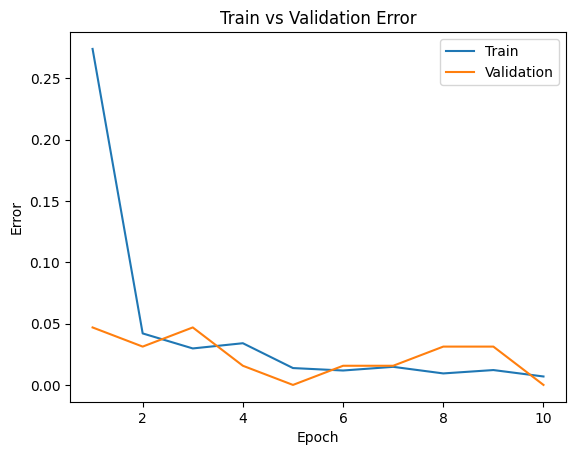

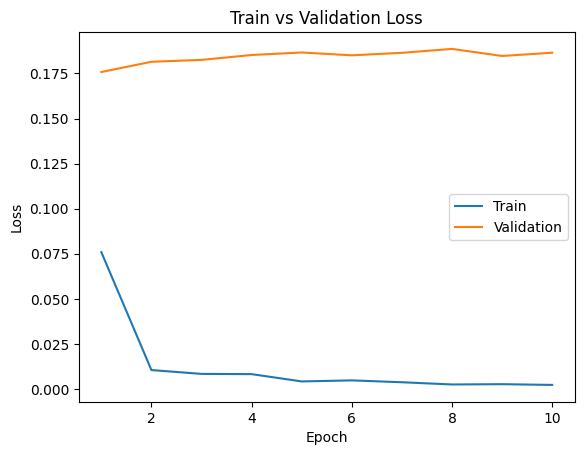

Currently loading data from /content/datasets/indian_food/
predictions are: tensor([1, 1, 1, 2, 2, 0, 1, 3, 1, 1, 2, 2, 0, 1, 0, 3, 0, 1, 3, 1, 1, 0, 1, 1,
        3, 0, 0, 3, 0, 2, 2, 3, 3, 2, 2, 3, 0, 3, 0, 1, 0, 3, 3, 2, 1, 2, 1, 3,
        0, 2, 1, 3, 3, 3, 0, 1, 1, 3, 1, 1, 2, 2, 2, 0], dtype=torch.int32)
labels are: tensor([1, 1, 1, 2, 2, 0, 1, 3, 1, 1, 2, 2, 0, 1, 0, 3, 0, 1, 3, 1, 1, 1, 1, 1,
        3, 0, 0, 3, 0, 2, 2, 3, 3, 2, 2, 3, 0, 3, 0, 1, 0, 3, 3, 2, 1, 2, 1, 3,
        0, 2, 1, 3, 3, 3, 0, 1, 1, 3, 1, 1, 2, 2, 2, 0])
total wrong is 1 out of 64, accuracy is 0.984375
1 64 0.015625

Test Error: 0.015625
Test Loss: 0.025525530576705934
Test Accuracy: 0.984375


In [ ]:
# Load the trained model
model_path = get_model_name("primary", batch_size=64, learning_rate=0.001, epoch=9)

# Plot training curves
plot_training_curve(model_path)

# Get data loaders
train_loader, val_loader, test_loader, classes = get_data_loader(target_filters, target_data, batch_size=64)

# Evaluate on test set
test_err, test_loss = evaluate(primary, test_loader, nn.CrossEntropyLoss(), target_filters)
test_err = count_error(primary, test_loader, target_filters)
test_accuracy = 1 - test_err  # Accuracy is the inverse of error
print("Test Error:", test_err)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Inputs size: torch.Size([64, 3, 150, 150]), Labels size: torch.Size([64]), Predictions size: torch.Size([64])


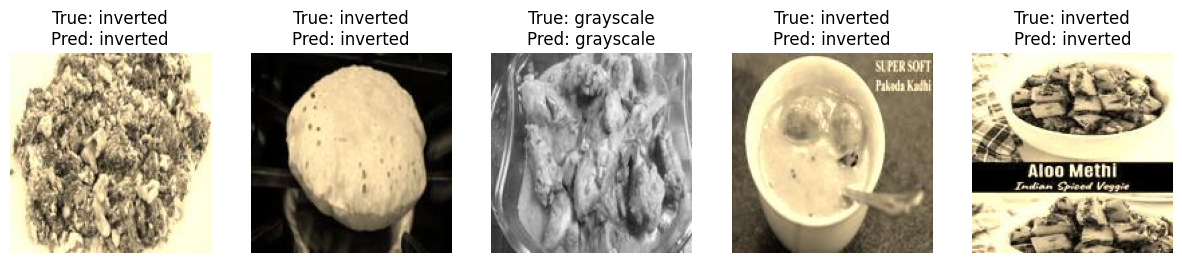

In [ ]:
def show_predictions(net, loader, classes, num_samples=5):
    """Show predictions on random samples from the test set."""
    net.eval()  # Set model to evaluation mode

    for inputs, labels in loader:
        #outputs = net(inputs)  # Get model predictions
        #predictions = torch.argmax(outputs, dim=1)  # Predicted classes

        outputs = torch.sigmoid(net(inputs))

        classified_outputs = []
        np_outputs = outputs.detach().numpy()

        for i in range(np_outputs.shape[0]):
            classified_outputs.append(classify_abcd(np_outputs[i].reshape((3, 4))))

        predictions = torch.IntTensor(classified_outputs)

        # Ensure batch sizes are consistent
        print(f"Inputs size: {inputs.size()}, Labels size: {labels.size()}, Predictions size: {predictions.size()}")

        if labels.size(0) != predictions.size(0):
            print("Mismatch detected between labels and predictions size! Skipping this batch.")
            continue

        batch_size = inputs.size(0)
        num_samples = min(num_samples, batch_size)

        plt.figure(figsize=(15, 5))

        for i in range(num_samples):
            # Safeguard against out-of-bound indexing
            if i >= labels.size(0) or i >= predictions.size(0):
                print(f"Skipping sample {i} due to mismatched sizes.")
                continue

            # Validate prediction index
            pred_idx = predictions[i].item()
            if pred_idx < 0 or pred_idx >= len(classes):
                print(f"Skipping sample {i}: Prediction index {pred_idx} is out of bounds for classes.")
                continue

            # Convert image to numpy format for display
            img = inputs[i].permute(1, 2, 0).cpu().numpy()  # Convert tensor to image
            img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize

            true_label = classes[labels[i].item()]
            pred_label = classes[pred_idx]

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {pred_label}")
            plt.axis("off")

        plt.show()
        break  # Only visualize one batch


# Call this function to visualize predictions

show_predictions(primary, test_loader, classes)

Inputs size: torch.Size([64, 3, 150, 150]), Labels size: torch.Size([64]), Predictions size: torch.Size([64])


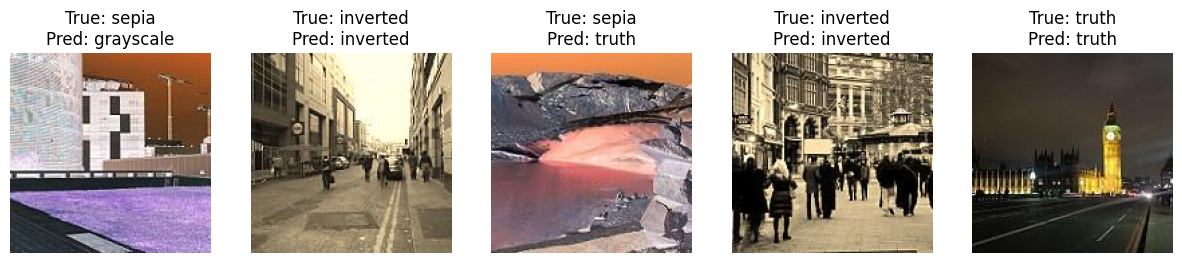

In [ ]:
def show_predictions(net, loader, classes, num_samples=5):
    """Show predictions on random samples from the test set."""
    net.eval()  # Set model to evaluation mode

    for inputs, labels in loader:
        #outputs = net(inputs)  # Get model predictions
        #predictions = torch.argmax(outputs, dim=1)  # Predicted classes

        outputs = torch.sigmoid(net(inputs))

        classified_outputs = []
        np_outputs = outputs.detach().numpy()

        for i in range(np_outputs.shape[0]):
            classified_outputs.append(classify_abcd(np_outputs[i].reshape((3, 4))))

        predictions = torch.IntTensor(classified_outputs)

        # Ensure batch sizes are consistent
        print(f"Inputs size: {inputs.size()}, Labels size: {labels.size()}, Predictions size: {predictions.size()}")

        if labels.size(0) != predictions.size(0):
            print("Mismatch detected between labels and predictions size! Skipping this batch.")
            continue

        batch_size = inputs.size(0)
        num_samples = min(num_samples, batch_size)

        plt.figure(figsize=(15, 5))

        for i in range(num_samples):
            # Safeguard against out-of-bound indexing
            if i >= labels.size(0) or i >= predictions.size(0):
                print(f"Skipping sample {i} due to mismatched sizes.")
                continue

            # Validate prediction index
            pred_idx = predictions[i].item()
            if pred_idx < 0 or pred_idx >= len(classes):
                print(f"Skipping sample {i}: Prediction index {pred_idx} is out of bounds for classes.")
                continue

            # Convert image to numpy format for display
            img = inputs[i].permute(1, 2, 0).cpu().numpy()  # Convert tensor to image
            img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize

            true_label = classes[labels[i].item()]
            pred_label = classes[pred_idx]

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {pred_label}")
            plt.axis("off")

        plt.show()
        break  # Only visualize one batch


# Call this function to visualize predictions

show_predictions(primary, test_loader, classes)

up till this point

# Predict a landscape image (new data) with a model that has only been trained on Indian Foods

Currently loading data from /content/datasets/landscapes/
predictions are: tensor([1, 0, 0, 0, 2, 3, 1, 0, 2, 2, 2, 0, 1, 1, 3, 2, 0, 2, 0, 2, 0, 2, 0, 0,
        0, 2, 3, 1, 3, 0, 0, 0, 2, 2, 3, 0, 1, 2, 0, 3, 0, 0, 2, 1, 2, 0, 3, 3,
        2, 2, 3, 0, 0, 0, 0, 3, 1, 0, 1, 0, 0, 3, 0, 3], dtype=torch.int32)
labels are: tensor([3, 0, 0, 1, 2, 1, 3, 0, 2, 2, 2, 0, 1, 1, 1, 1, 0, 2, 0, 2, 0, 3, 0, 0,
        0, 2, 3, 1, 3, 0, 1, 3, 2, 2, 1, 3, 3, 2, 3, 1, 0, 3, 2, 1, 2, 0, 1, 1,
        2, 3, 1, 0, 1, 0, 0, 3, 3, 0, 1, 3, 3, 1, 0, 1])
total wrong is 25 out of 64, accuracy is 0.609375
25 64 0.390625

Inputs size: torch.Size([64, 3, 150, 150]), Labels size: torch.Size([64]), Predictions size: torch.Size([64])


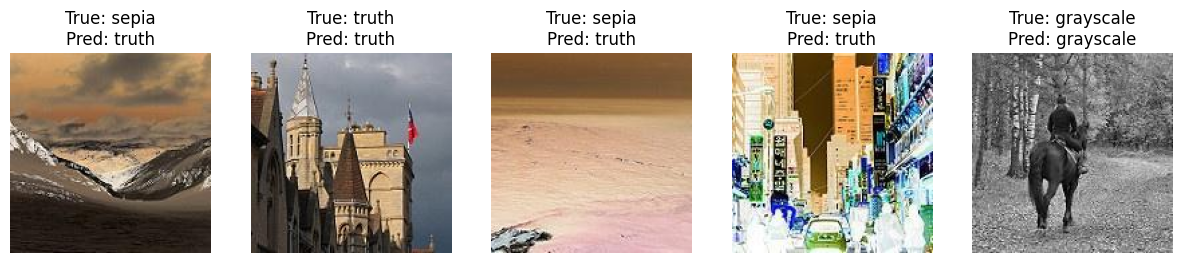

Inputs size: torch.Size([64, 3, 150, 150]), Labels size: torch.Size([64]), Predictions size: torch.Size([64])


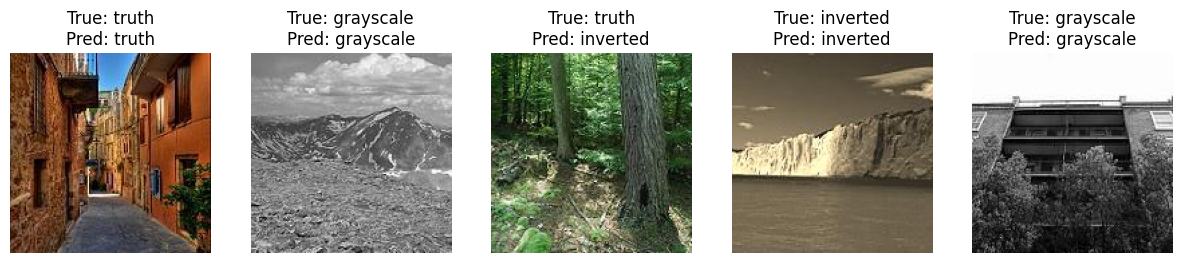

In [ ]:
target_filters = ["grayscale", "inverted", "sepia", "truth"]
target_data = ["landscapes"]

train_loader, val_loader, test_loader, classes = get_data_loader(target_filters, target_data, batch_size=64)

test_err = count_error(primary, test_loader, target_filters)

show_predictions(primary, test_loader, classes, num_samples=5)
show_predictions(primary, test_loader, classes, num_samples=5)

In [ ]:
target_filters = ["grayscale", "inverted", "sepia", "truth"]
target_data = ["landscapes"]

train_loader, val_loader, test_loader, classes = get_data_loader(target_filters, target_data, batch_size=64)


Currently loading data from /content/datasets/landscapes/


Label: 3, Applied Filter: truth


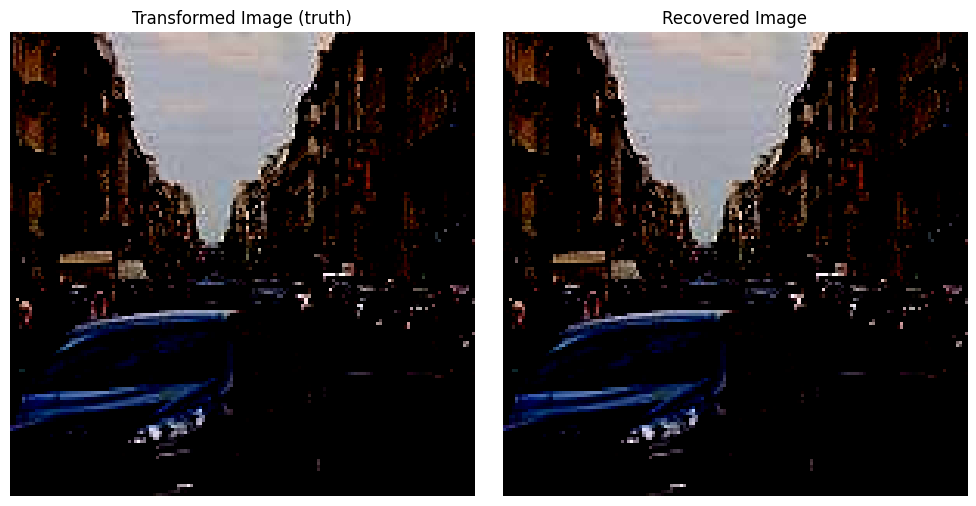

Label: 0, Applied Filter: grayscale
Error in reverse transformation for filter 'grayscale': Coefficient matrix is not invertible. Check the coefficients.
Label: 2, Applied Filter: sepia


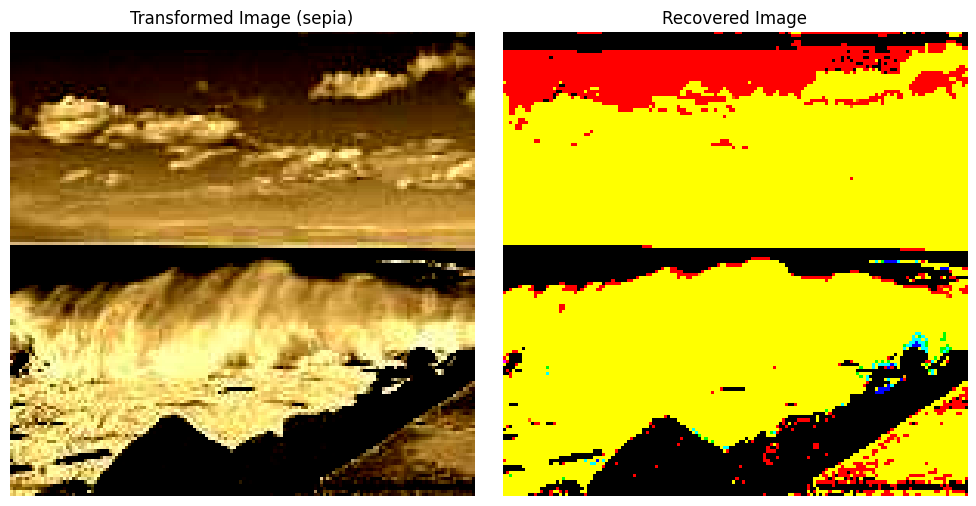

Label: 2, Applied Filter: sepia


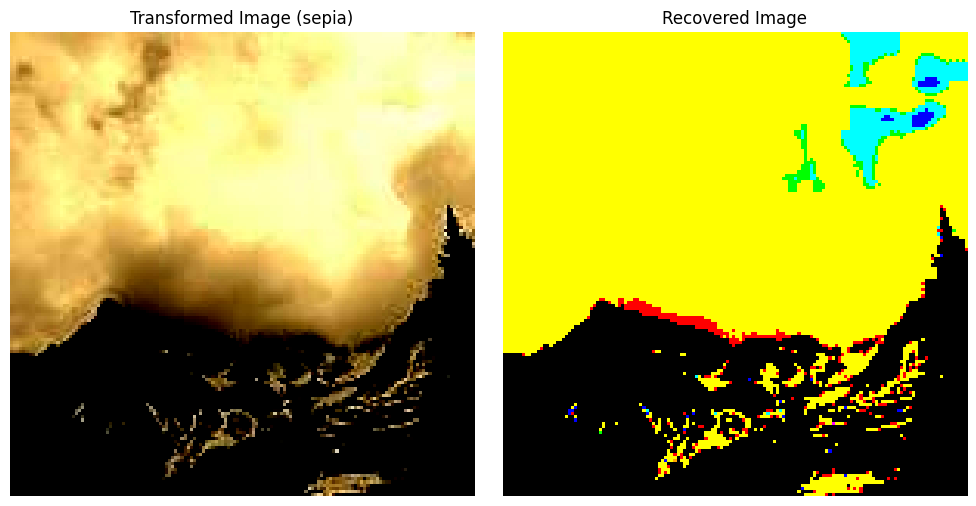

Label: 2, Applied Filter: sepia


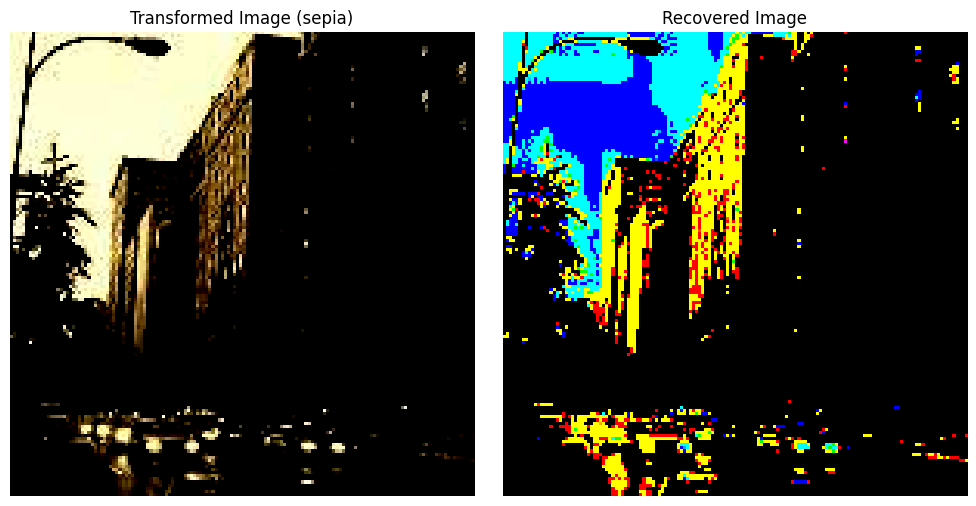

In [ ]:
# Iterate through a few batches from the test_loader
for inputs, labels in test_loader:
    # Visualize the first 5 images in the batch
    for i in range(min(5, inputs.size(0))):  # Safeguard against batch size less than 5
        transformed_image = inputs[i].permute(1, 2, 0).cpu().numpy()  # Convert to HxWxC format

        # Scale pixel values to [0, 255] for visualization (if necessary)
        transformed_image = (transformed_image * 255).clip(0, 255).astype(np.uint8)

        # Debugging: Print the label and corresponding filter
        label = labels[i].item()
        print(f"Label: {label}, Applied Filter: {target_filters[label]}")

        # Get the applied filter and coefficients
        applied_filter = target_filters[label]
        truth_abcd = get_truth_abcd(applied_filter)
        coefficients = {
            'red': truth_abcd[0],
            'green': truth_abcd[1],
            'blue': truth_abcd[2]
        }

        try:
            # Apply reverse transformation
            recovered_image = reverse_transformation(transformed_image, coefficients)

            # Ensure recovered image is in valid range
            recovered_image = recovered_image.clip(0, 255).astype(np.uint8)
        except ValueError as e:
            print(f"Error in reverse transformation for filter '{applied_filter}': {e}")
            continue  # Skip to next image if transformation fails

        # Visualize the transformed and recovered images
        plt.figure(figsize=(10, 5))

        # Display transformed image
        plt.subplot(1, 2, 1)
        plt.title(f"Transformed Image ({applied_filter})")
        plt.imshow(transformed_image)
        plt.axis('off')

        # Display recovered image
        plt.subplot(1, 2, 2)
        plt.title("Recovered Image")
        plt.imshow(recovered_image)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    # Stop after visualizing one batch
    break


Label: 2, Applied Filter: sepia


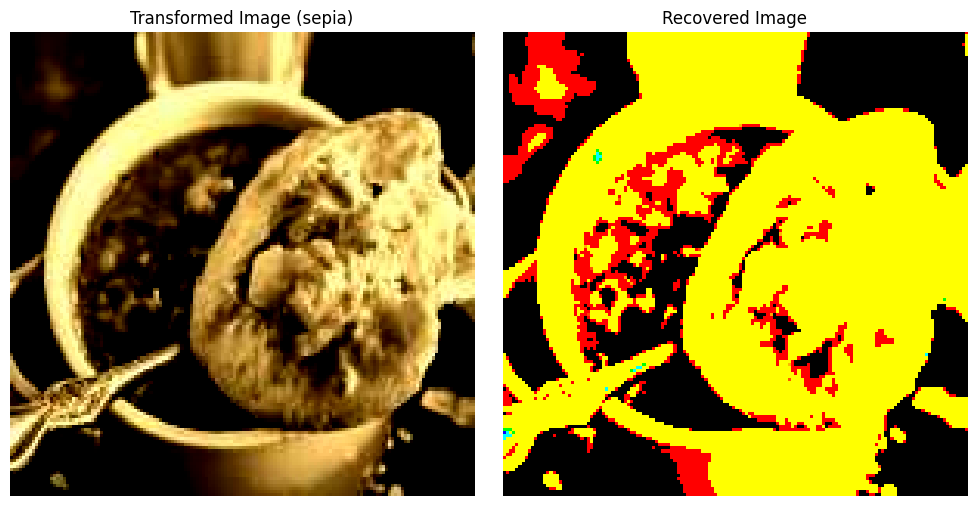

Label: 3, Applied Filter: truth


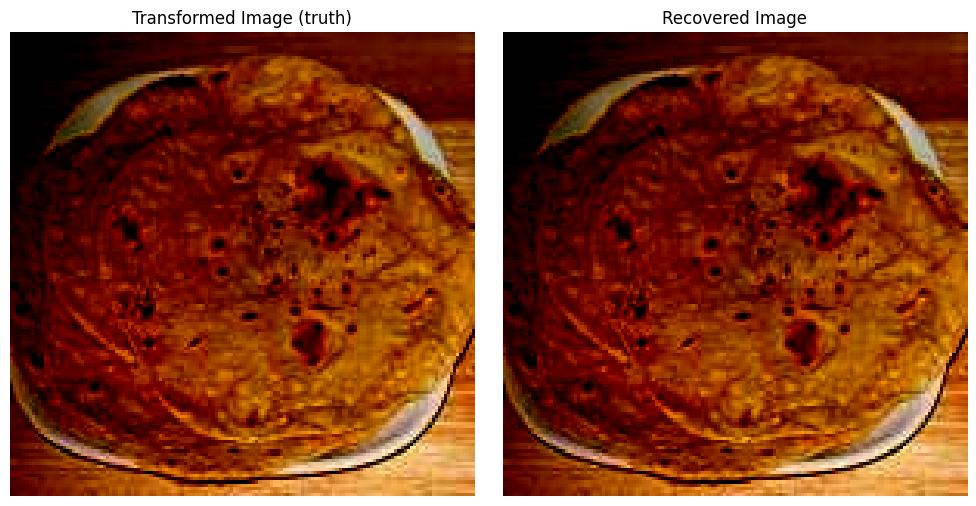

Label: 3, Applied Filter: truth


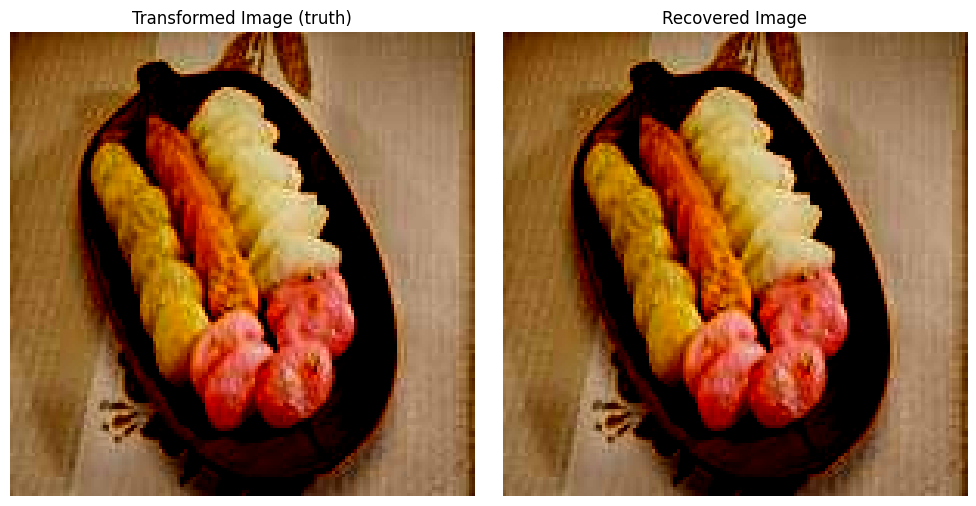

Label: 1, Applied Filter: inverted


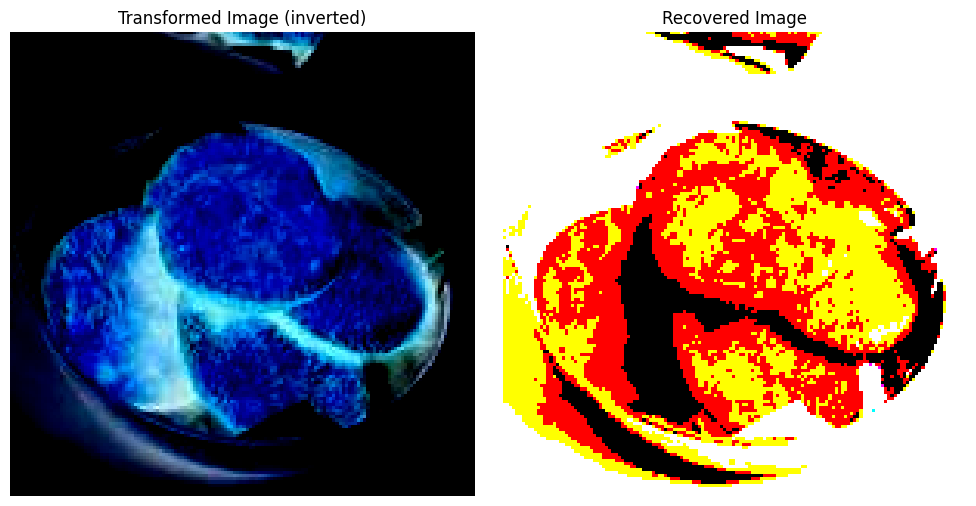

Label: 1, Applied Filter: inverted


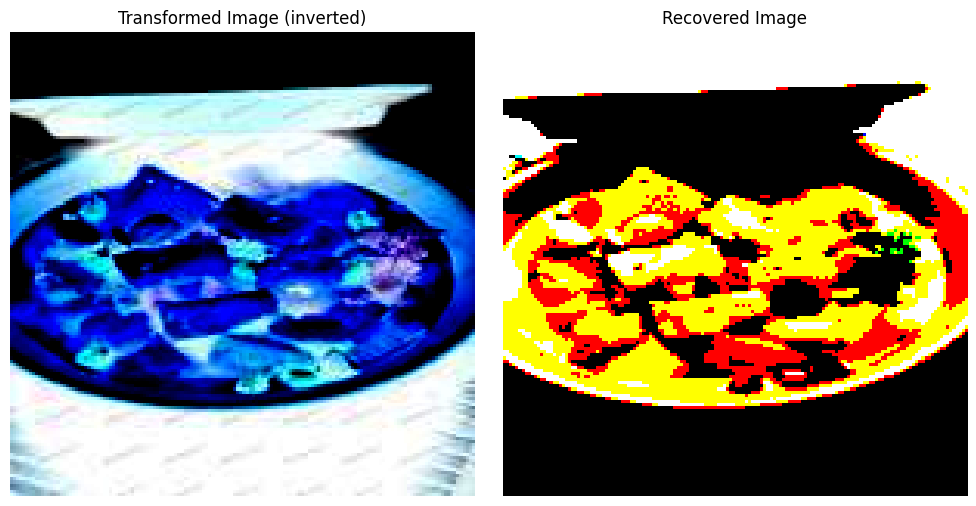

In [ ]:
# Iterate through a few batches from the test_loader
for inputs, labels in test_loader:
    # Visualize the first 5 images in the batch
    for i in range(min(5, inputs.size(0))):  # Safeguard against batch size less than 5
        transformed_image = inputs[i].permute(1, 2, 0).cpu().numpy()  # Convert to HxWxC format

        # Scale pixel values to [0, 255] for visualization (if necessary)
        transformed_image = (transformed_image * 255).clip(0, 255).astype(np.uint8)

        # Debugging: Print the label and corresponding filter
        label = labels[i].item()
        print(f"Label: {label}, Applied Filter: {target_filters[label]}")

        # Get the applied filter and coefficients
        applied_filter = target_filters[label]
        truth_abcd = get_truth_abcd(applied_filter)
        coefficients = {
            'red': truth_abcd[0],
            'green': truth_abcd[1],
            'blue': truth_abcd[2]
        }

        try:
            # Apply reverse transformation
            recovered_image = reverse_transformation(transformed_image, coefficients)

            # Ensure recovered image is in valid range
            recovered_image = recovered_image.clip(0, 255).astype(np.uint8)
        except ValueError as e:
            print(f"Error in reverse transformation for filter '{applied_filter}': {e}")
            continue  # Skip to next image if transformation fails

        # Visualize the transformed and recovered images
        plt.figure(figsize=(10, 5))

        # Display transformed image
        plt.subplot(1, 2, 1)
        plt.title(f"Transformed Image ({applied_filter})")
        plt.imshow(transformed_image)
        plt.axis('off')

        # Display recovered image
        plt.subplot(1, 2, 2)
        plt.title("Recovered Image")
        plt.imshow(recovered_image)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    # Stop after visualizing one batch
    break


Inputs size: torch.Size([64, 3, 150, 150]), Labels size: torch.Size([64]), Predictions size: torch.Size([64])
Skipping sample 0: Prediction index 5 is out of bounds for classes.
Skipping sample 1: Prediction index 5 is out of bounds for classes.
Skipping sample 2: Prediction index 5 is out of bounds for classes.
Skipping sample 3: Prediction index 7 is out of bounds for classes.


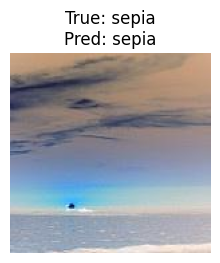

In [ ]:
def show_predictions(net, loader, classes, num_samples=5):
    """Show predictions on random samples from the test set."""
    net.eval()  # Set model to evaluation mode

    for inputs, labels in loader:
        outputs = net(inputs)  # Get model predictions
        predictions = torch.argmax(outputs, dim=1)  # Predicted classes

        # Ensure batch sizes are consistent
        print(f"Inputs size: {inputs.size()}, Labels size: {labels.size()}, Predictions size: {predictions.size()}")

        if labels.size(0) != predictions.size(0):
            print("Mismatch detected between labels and predictions size! Skipping this batch.")
            continue

        batch_size = inputs.size(0)
        num_samples = min(num_samples, batch_size)

        plt.figure(figsize=(15, 5))

        for i in range(num_samples):
            # Safeguard against out-of-bound indexing
            if i >= labels.size(0) or i >= predictions.size(0):
                print(f"Skipping sample {i} due to mismatched sizes.")
                continue

            # Validate prediction index
            pred_idx = predictions[i].item()
            if pred_idx < 0 or pred_idx >= len(classes):
                print(f"Skipping sample {i}: Prediction index {pred_idx} is out of bounds for classes.")
                continue

            # Convert image to numpy format for display
            img = inputs[i].permute(1, 2, 0).cpu().numpy()  # Convert tensor to image
            img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize

            true_label = classes[labels[i].item()]
            pred_label = classes[pred_idx]

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {pred_label}")
            plt.axis("off")

        plt.show()
        break  # Only visualize one batch


# Call this function to visualize predictions
show_predictions(primary, test_loader, classes)

# Regression

For regression, need new way of calculating loss. Model will guess the 9 RGB coefficents and 3 RGB biases. Loss calculated from this.

In [ ]:
import math

def get_truth_abcd(filter):
  # returns a, b, c, and d for each of the three channels
  # where new_channel = a*old_red + b*old_green + c*old_blue + d
  # ["grayscale", "sepia", "inverted"]

  # abcd = [ [red_a, red_b, red_c, red_d],
  #          [green_a, green_b, green_c, green_d],
  #          [blue_a, blue_b, blue_c, blue_d]]

  abcd = []
  if filter == 'grayscale':
    abcd.append([0.299, 0.587, 0.114, 0.0]) # red
    abcd.append([0.299, 0.587, 0.114, 0.0]) # green
    abcd.append([0.299, 0.587, 0.114, 0.0]) # blue

  elif filter == 'sepia':
    abcd.append([0.393, 0.769, 0.189, 0.0]) # red
    abcd.append([0.349, 0.686, 0.168, 0.0]) # green
    abcd.append([0.272, 0.534, 0.131, 0.0]) # blue


  elif filter == 'inverted':
    abcd.append([-1.0/255.0, 0.0, 0.0, 1]) # red
    abcd.append([0.0, -1.0/255.0, 0.0, 1]) # green
    abcd.append([0.0, 0.0, -1.0/255.0, 1]) # blue

  elif filter == 'truth':
    abcd.append([1.0, 0.0, 0.0, 0.0]) # red
    abcd.append([0.0, 1.0, 0.0, 0.0]) # green
    abcd.append([0.0, 0.0, 1.0, 0.0]) # blue

     # elif filter == 'inverted':
  #   abcd.append([-1.0, 0.0, 0.0, 255.0]) # red
  #   abcd.append([0.0, -1.0, 0.0, 255.0]) # green
  #   abcd.append([0.0, 0.0, -1.0, 255.0]) # blue

  return abcd

def rmse(pred_abcd, true_abcd):

  rmse = 0.0
  for i in range(len(true_abcd)):
    for j in range(len(pred_abcd[0])):
      rmse += (pred_abcd[i][j] - true_abcd[i][j])**2

  rmse = rmse/12
  rmse = math.sqrt(rmse)

  return rmse

def classify_abcd(pred_abcd, filters=['grayscale', 'sepia', 'inverted', 'truth']):

  filters_rmse = []
  for filter in filters:
    filters_rmse.append(rmse(pred_abcd, get_truth_abcd(filter)))

  idx_closest_filter = min(range(len(filters_rmse)), key=filters_rmse.__getitem__)

  return idx_closest_filter

'''
e.g.
pred_abcd = model(img_x) # this spits out 12 real outputs now rather than a single neuron output

true_abcd = get_truth_abcd(img_x.label) # img_x.label would be string 'grayscale' or whatever

error = rmse(pred_abcd, true_abcd)

'''

"\ne.g.\npred_abcd = model(img_x) # this spits out 12 real outputs now rather than a single neuron output\n\ntrue_abcd = get_truth_abcd(img_x.label) # img_x.label would be string 'grayscale' or whatever\n\nerror = rmse(pred_abcd, true_abcd)\n\n"

This function takes in the coefficients a,b,c,d for each channel and reverses the transformation to recover the original pixel intensities.

In [ ]:
import numpy as np

def reverse_transformation(image, coefficients):
    """
    Args:
        image (numpy.ndarray): The transformed image (H x W x 3).
        coefficients (dict): A dictionary containing the coefficients for the transformation:
            - 'red': [a_r, b_r, c_r, d_r]
            - 'green': [a_g, b_g, c_g, d_g]
            - 'blue': [a_b, b_b, c_b, d_b]

    Returns:
        numpy.ndarray: The recovered image (H x W x 3) with original RGB intensities.
    """
    # Extract coefficients for each channel
    a_r, b_r, c_r, d_r = coefficients['red']
    a_g, b_g, c_g, d_g = coefficients['green']
    a_b, b_b, c_b, d_b = coefficients['blue']

    # Construct the coefficient matrix and bias vector
    C = np.array([[a_r, b_r, c_r],
                  [a_g, b_g, c_g],
                  [a_b, b_b, c_b]])
    d = np.array([d_r, d_g, d_b])

    # Ensure invertibility of the coefficient matrix
    if np.linalg.det(C) == 0: #linear alg
        raise ValueError("Coefficient matrix is not invertible. Check the coefficients.")

    # Invert the coefficient matrix
    C_inv = np.linalg.inv(C)

    # Recover the original pixel values
    H, W, _ = image.shape
    recovered_image = np.zeros_like(image, dtype=np.float32)

    for i in range(H):
        for j in range(W):
            p_new = image[i, j, :].astype(np.float32)  # New pixel intensities
            p_old = C_inv @ (p_new - d)  # Apply the inverse transformation
            recovered_image[i, j, :] = np.clip(p_old, 0, 255)  # Clip values to valid range

    return recovered_image.astype(np.uint8)

'''
e.g.
# Load a transformed image
transformed_image = np.random.randint(0, 256, (150, 150, 3), dtype=np.uint8)  # Example image

# Specify the filter applied to the image
applied_filter = 'sepia'

# Get the true coefficients for the filter
truth_abcd = get_truth_abcd(applied_filter)

# Format coefficients for the reverse_transformation function
coefficients = {
    'red': truth_abcd[0],
    'green': truth_abcd[1],
    'blue': truth_abcd[2]
}

# Reverse the transformation
recovered_image = reverse_transformation(transformed_image, coefficients)

# Visualize the transformed and recovered images
plt.subplot(1, 2, 1)
plt.title("Transformed Image")
plt.imshow(transformed_image)

plt.subplot(1, 2, 2)
plt.title("Recovered Image")
plt.imshow(recovered_image)
plt.show()

'''


'\ne.g.\n# Load a transformed image\ntransformed_image = np.random.randint(0, 256, (150, 150, 3), dtype=np.uint8)  # Example image\n\n# Specify the filter applied to the image\napplied_filter = \'sepia\'\n\n# Get the true coefficients for the filter\ntruth_abcd = get_truth_abcd(applied_filter)\n\n# Format coefficients for the reverse_transformation function\ncoefficients = {\n    \'red\': truth_abcd[0],\n    \'green\': truth_abcd[1],\n    \'blue\': truth_abcd[2]\n}\n\n# Reverse the transformation\nrecovered_image = reverse_transformation(transformed_image, coefficients)\n\n# Visualize the transformed and recovered images\nplt.subplot(1, 2, 1)\nplt.title("Transformed Image")\nplt.imshow(transformed_image)\n\nplt.subplot(1, 2, 2)\nplt.title("Recovered Image")\nplt.imshow(recovered_image)\nplt.show()\n\n'